<a href="https://colab.research.google.com/github/victoriaspradlin/SML312FinalProject/blob/main/County_Level_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
# County-Level Machine Learning Pipeline
# Goal: predict mental health using ACS commute variables + CDC PLACES health data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [10]:
# Mount Drive and load datasets

drive.mount("/content/drive")

data_path = "/content/drive/MyDrive/SML312Project/data/"

print(os.listdir(data_path))

places = pd.read_csv(
    data_path + "PLACES__Local_Data_for_Better_Health,_County_Data,_2025_release_20260430.csv",
    low_memory=False,
    dtype=str
)

acs = pd.read_csv(
    data_path + "ACSDT5Y2024.B08301-Data.csv"
)

places.head(), acs.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['2015.csv', 'ACSDT5Y2024.B08301-Data.csv', 'ACSDT5YSPT2015.B08301-Column-Metadata.csv', 'ACSDT5YSPT2015.B08301-Data.csv', 'ACSDT5Y2015.B19013-Data.csv', 'ACSDT5Y2015.B19013-Column-Metadata.csv', 'ACSDT5Y2015.B15003-Data.csv', 'ACSDT5Y2015.B23025-Data.csv', 'ACSDT5YSPT2015.B01003-Data.csv', 'ACSDT5Y2015.B08303-Data.csv', 'PLACES__Local_Data_for_Better_Health,_County_Data,_2025_release_20260430.csv']


(   Year StateAbbr StateDesc LocationName DataSource         Category  \
 0  2023        AR  Arkansas         Drew      BRFSS  Health Outcomes   
 1  2023        AR  Arkansas       Fulton      BRFSS  Health Outcomes   
 2  2023        AR  Arkansas       Howard      BRFSS  Health Outcomes   
 3  2023        AR  Arkansas       Miller      BRFSS  Health Outcomes   
 4  2023        AR  Arkansas     Ouachita      BRFSS       Disability   
 
                        Measure Data_Value_Unit   Data_Value_Type Data_Value  \
 0       Arthritis among adults               %  Crude prevalence       29.9   
 1  Current asthma among adults               %  Crude prevalence       10.6   
 2       Arthritis among adults               %  Crude prevalence       31.2   
 3          Stroke among adults               %  Crude prevalence        4.7   
 4  Any disability among adults               %  Crude prevalence       42.8   
 
    ... Low_Confidence_Limit High_Confidence_Limit TotalPopulation  \
 0  ... 

In [11]:
# Create FIPS codes

places["FIPS"] = places["LocationID"].astype(str).str.zfill(5)
acs["FIPS"] = acs["GEO_ID"].astype(str).str[-5:]

print(places[["LocationID", "FIPS"]].head())
print(acs[["GEO_ID", "FIPS"]].head())

  LocationID   FIPS
0      05043  05043
1      05049  05049
2      05061  05061
3      05091  05091
4      05103  05103
           GEO_ID   FIPS
0       Geography  raphy
1  0500000US01001  01001
2  0500000US01003  01003
3  0500000US01005  01005
4  0500000US01007  01007


In [12]:
# Clean ACS commute variables

# Remove metadata/header row if present
acs = acs[acs["GEO_ID"].astype(str).str.contains("US", na=False)].copy()

# FIPS: last 5 digits of GEO_ID
acs["FIPS"] = acs["GEO_ID"].str[-5:]

# Convert commute columns to numeric
acs["total_commuters"] = pd.to_numeric(acs["B08301_001E"], errors="coerce")
acs["drive_alone"] = pd.to_numeric(acs["B08301_003E"], errors="coerce")
acs["public_transit"] = pd.to_numeric(acs["B08301_010E"], errors="coerce")
acs["long_commute"] = pd.to_numeric(acs["B08301_013E"], errors="coerce")

# Construct commute shares
acs["drive_alone_share"] = acs["drive_alone"] / acs["total_commuters"]
acs["public_transit_share"] = acs["public_transit"] / acs["total_commuters"]
acs["long_commute_share"] = acs["long_commute"] / acs["total_commuters"]

# Keep cleaned commute variables
acs_clean = acs[
    [
        "FIPS",
        "drive_alone_share",
        "public_transit_share",
        "long_commute_share"
    ]
].copy()

acs_clean.head()

,FIPS,drive_alone_share,public_transit_share,long_commute_share
1,01001,0.843044,0.000518,0.0
2,01003,0.794437,0.000880,0.0
3,01005,0.832330,0.000000,0.0
4,01007,0.848439,0.007301,0.0
5,01009,0.843951,0.000000,0.0


In [13]:
# Clean PLACES mental health outcome

# Keep only the two mental health measures we want
places_mh = places[
    places["MeasureId"].isin(["MHLTH", "DEPRESSION"])
].copy()

# Keep useful columns
places_mh = places_mh[
    ["FIPS", "LocationName", "StateAbbr", "MeasureId", "Data_Value"]
]

# Convert Data_Value to numeric
places_mh["Data_Value"] = pd.to_numeric(places_mh["Data_Value"], errors="coerce")

# Pivot from long format to wide format
places_clean = places_mh.pivot_table(
    index=["FIPS", "LocationName", "StateAbbr"],
    columns="MeasureId",
    values="Data_Value"
).reset_index()

# Rename outcomes clearly
places_clean = places_clean.rename(columns={
    "MHLTH": "frequent_mental_distress",
    "DEPRESSION": "depression_prevalence"
})

places_clean.head()

MeasureId,FIPS,LocationName,StateAbbr,depression_prevalence,frequent_mental_distress
0,01001,Autauga,AL,25.5,17.50
1,01003,Baldwin,AL,23.2,15.95
2,01005,Barbour,AL,22.5,19.20
3,01007,Bibb,AL,24.7,19.40
4,01009,Blount,AL,25.4,18.20


In [14]:
# Merge datasets

county = places_clean.merge(
    acs_clean,
    on="FIPS",
    how="inner"
)

county.head()

,FIPS,LocationName,StateAbbr,depression_prevalence,frequent_mental_distress,drive_alone_share,public_transit_share,long_commute_share
0,01001,Autauga,AL,25.5,17.50,0.843044,0.000518,0.0
1,01003,Baldwin,AL,23.2,15.95,0.794437,0.000880,0.0
2,01005,Barbour,AL,22.5,19.20,0.832330,0.000000,0.0
3,01007,Bibb,AL,24.7,19.40,0.848439,0.007301,0.0
4,01009,Blount,AL,25.4,18.20,0.843951,0.000000,0.0


In [15]:
# Build expanded county-level modeling dataset

features = [
    "drive_alone_share",
    "public_transit_share",
    "long_commute_share"
]

targets = [
    "frequent_mental_distress",
    "depression_prevalence"
]

county_model = county[features + targets].dropna()

print(county_model.shape)
county_model.head()

(2956, 5)


,drive_alone_share,public_transit_share,long_commute_share,frequent_mental_distress,depression_prevalence
0,0.843044,0.000518,0.0,17.50,25.5
1,0.794437,0.000880,0.0,15.95,23.2
2,0.832330,0.000000,0.0,19.20,22.5
3,0.848439,0.007301,0.0,19.40,24.7
4,0.843951,0.000000,0.0,18.20,25.4


In [16]:
# Define X and Y

X = county_model[features]

# Main target variable
y = county_model["frequent_mental_distress"]

In [17]:
# Train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Exploratory Data Analysis

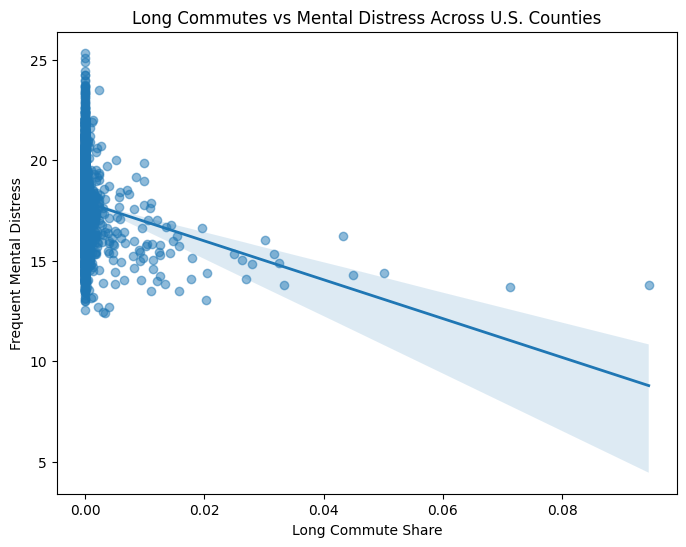

In [18]:
# EDA: Long Commute Share vs Mental Distress

plt.figure(figsize=(8,6))

sns.regplot(
    data=county_model,
    x="long_commute_share",
    y="frequent_mental_distress",
    scatter_kws={"alpha":0.5},
    line_kws={"linewidth":2}
)

plt.xlabel("Long Commute Share")
plt.ylabel("Frequent Mental Distress")
plt.title("Long Commutes vs Mental Distress Across U.S. Counties")

plt.show()


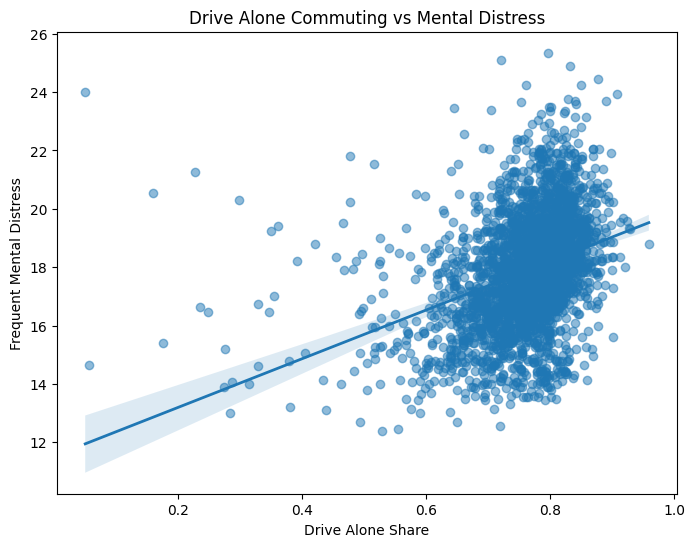

In [19]:
# EDA: Drive Alone Share vs Mental Distress

plt.figure(figsize=(8,6))

sns.regplot(
    data=county_model,
    x="drive_alone_share",
    y="frequent_mental_distress",
    scatter_kws={"alpha":0.5},
    line_kws={"linewidth":2}
)

plt.xlabel("Drive Alone Share")
plt.ylabel("Frequent Mental Distress")
plt.title("Drive Alone Commuting vs Mental Distress")

plt.show()

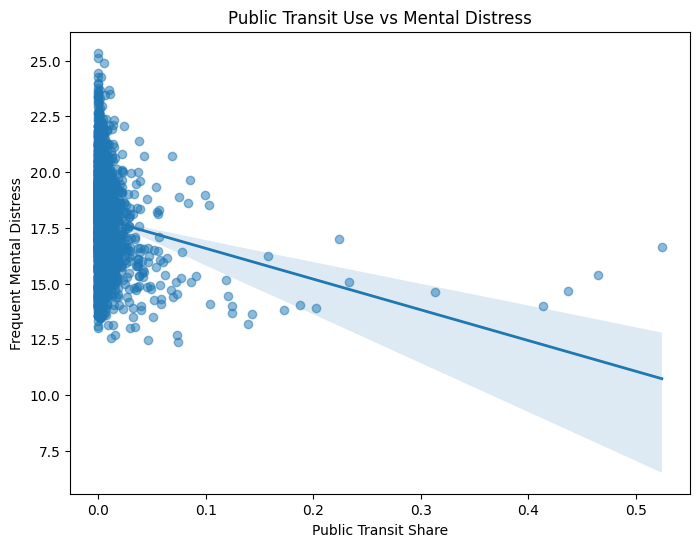

In [20]:
# EDA: Transit Share vs Mental Distress

plt.figure(figsize=(8,6))

sns.regplot(
    data=county_model,
    x="public_transit_share",
    y="frequent_mental_distress",
    scatter_kws={"alpha":0.5},
    line_kws={"linewidth":2}
)

plt.xlabel("Public Transit Share")
plt.ylabel("Frequent Mental Distress")
plt.title("Public Transit Use vs Mental Distress")

plt.show()

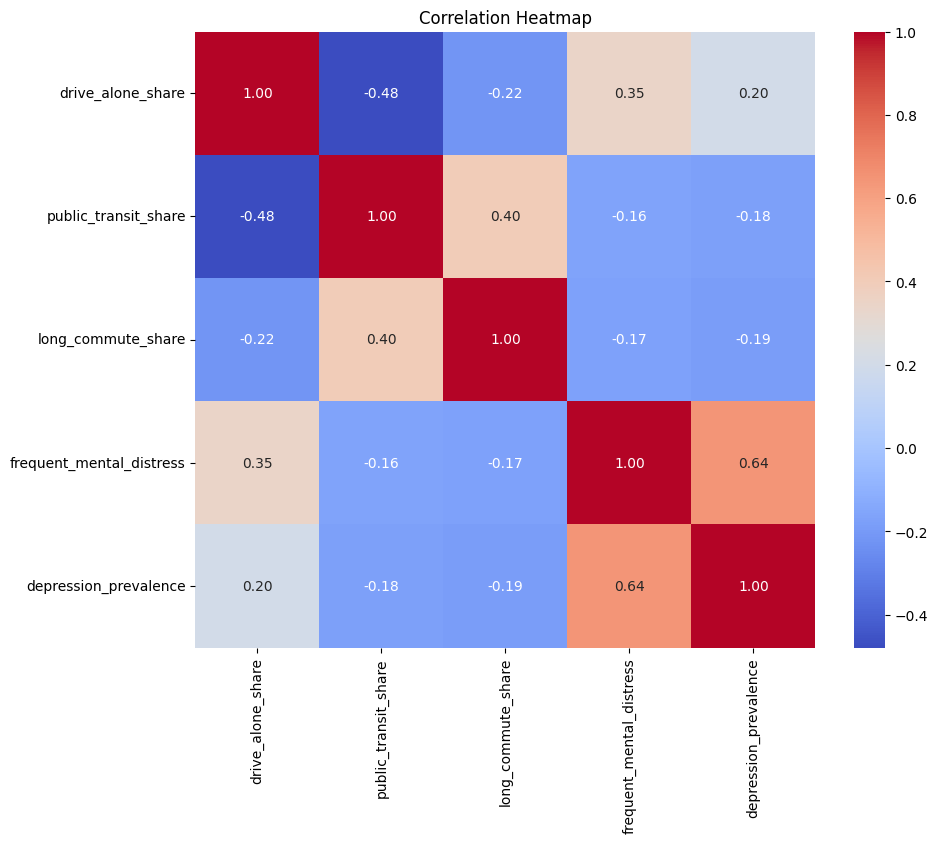

In [21]:
# Correlation Heatmap

plt.figure(figsize=(10,8))

corr = county_model.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

## PCA

In [22]:
transport_features = [
    "drive_alone_share",
    "public_transit_share",
    "long_commute_share"
]

pca_data = county[
    transport_features +
    ["frequent_mental_distress", "depression_prevalence"]
].dropna()

print(pca_data.shape)
pca_data.head()

(2956, 5)


,drive_alone_share,public_transit_share,long_commute_share,frequent_mental_distress,depression_prevalence
0,0.843044,0.000518,0.0,17.50,25.5
1,0.794437,0.000880,0.0,15.95,23.2
2,0.832330,0.000000,0.0,19.20,22.5
3,0.848439,0.007301,0.0,19.40,24.7
4,0.843951,0.000000,0.0,18.20,25.4


In [23]:
# PCA on Transportation Variables

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

transport_features = [
    "drive_alone_share",
    "public_transit_share",
    "long_commute_share"
]

X_transport = pca_data[transport_features]

# Standardize features before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_transport)

# PCA with 2 components
pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    pcs,
    columns=["PC1_car_dependence_index", "PC2_accessibility_index"]
)

pca_df["frequent_mental_distress"] = pca_data["frequent_mental_distress"].values
pca_df["depression_prevalence"] = pca_data["depression_prevalence"].values

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

pca_df.head()

Explained variance ratio:
[0.58156093 0.2610022 ]


,PC1_car_dependence_index,PC2_accessibility_index,frequent_mental_distress,depression_prevalence
0,-0.828440,0.545858,17.50,25.5
1,-0.476341,0.170295,15.95,23.2
2,-0.767730,0.465171,19.20,22.5
3,-0.674595,0.563617,19.40,24.7
4,-0.849464,0.554661,18.20,25.4


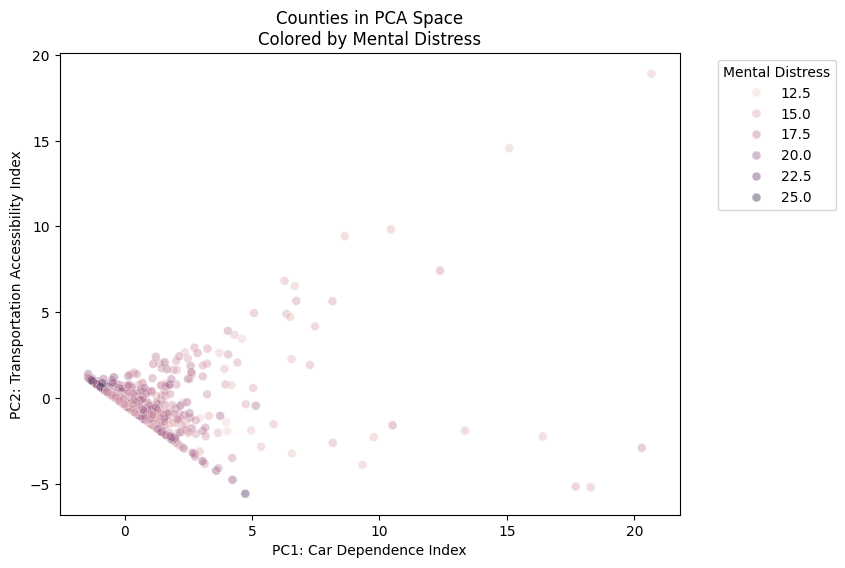

In [24]:
# PCA Visualization

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1_car_dependence_index",
    y="PC2_accessibility_index",
    hue="frequent_mental_distress",
    alpha=0.4,
    s=40
)

plt.title("Counties in PCA Space\nColored by Mental Distress")
plt.xlabel("PC1: Car Dependence Index")
plt.ylabel("PC2: Transportation Accessibility Index")
plt.legend(title="Mental Distress", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

In [25]:
# PCA Loadings

loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=transport_features
)

loadings

,PC1,PC2
drive_alone_share,-0.566407,0.620154
public_transit_share,0.642788,-0.079726
long_commute_share,0.515758,0.780418


In [26]:
# Regression Using PCA Components

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

X_pca = pca_df[["PC1_car_dependence_index", "PC2_accessibility_index"]]
y_pca = pca_df["frequent_mental_distress"]

X_pca_train, X_pca_test, y_pca_train, y_pca_test = train_test_split(
    X_pca,
    y_pca,
    test_size=0.2,
    random_state=42
)

pca_lr = LinearRegression()
pca_lr.fit(X_pca_train, y_pca_train)

pca_preds = pca_lr.predict(X_pca_test)

pca_rmse = np.sqrt(mean_squared_error(y_pca_test, pca_preds))
pca_mae = mean_absolute_error(y_pca_test, pca_preds)
pca_r2 = r2_score(y_pca_test, pca_preds)

print("PCA REGRESSION RESULTS")
print("----------------------")
print("RMSE:", round(pca_rmse, 3))
print("MAE:", round(pca_mae, 3))
print("R²:", round(pca_r2, 3))

PCA REGRESSION RESULTS
----------------------
RMSE: 1.789
MAE: 1.382
R²: 0.063


## Clustering

In [27]:
# K-Means Clustering on Transportation Patterns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

cluster_features = [
    "drive_alone_share",
    "public_transit_share",
    "long_commute_share"
]

cluster_data = county[
    cluster_features +
    ["frequent_mental_distress", "depression_prevalence"]
].dropna()

# Standardize
scaler = StandardScaler()

X_cluster = scaler.fit_transform(
    cluster_data[cluster_features]
)

# KMeans
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_data["cluster"] = kmeans.fit_predict(X_cluster)

cluster_data.head()

,drive_alone_share,public_transit_share,long_commute_share,frequent_mental_distress,depression_prevalence,cluster
0,0.843044,0.000518,0.0,17.50,25.5,0
1,0.794437,0.000880,0.0,15.95,23.2,0
2,0.832330,0.000000,0.0,19.20,22.5,0
3,0.848439,0.007301,0.0,19.40,24.7,0
4,0.843951,0.000000,0.0,18.20,25.4,0


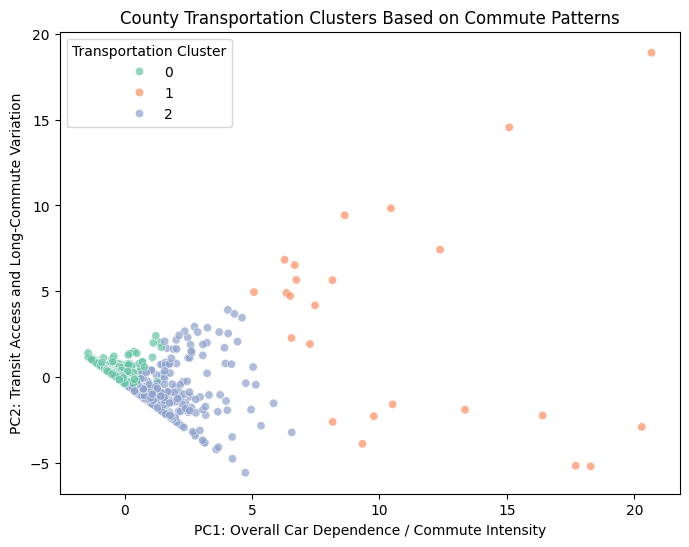

In [28]:
# Visualize Clusters in PCA Space

from sklearn.decomposition import PCA

pca_cluster = PCA(n_components=2)

cluster_pcs = pca_cluster.fit_transform(X_cluster)

cluster_plot = pd.DataFrame({
    "PC1": cluster_pcs[:,0],
    "PC2": cluster_pcs[:,1],
    "cluster": cluster_data["cluster"]
})

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=cluster_plot,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="Set2",
    alpha=0.7
)

plt.title("County Transportation Clusters Based on Commute Patterns")
plt.xlabel("PC1: Overall Car Dependence / Commute Intensity")
plt.ylabel("PC2: Transit Access and Long-Commute Variation")
plt.legend(title="Transportation Cluster")

plt.show()

In [29]:
# Mental Health by Cluster

cluster_summary = cluster_data.groupby("cluster")[
    [
        "drive_alone_share",
        "public_transit_share",
        "long_commute_share",
        "frequent_mental_distress",
        "depression_prevalence"
    ]
].mean()

cluster_summary

,drive_alone_share,public_transit_share,long_commute_share,frequent_mental_distress,depression_prevalence
cluster,,,,,
0,0.789440,0.002956,0.000104,18.176529,23.791653
1,0.487627,0.178043,0.026976,14.852083,17.025000
2,0.650710,0.013452,0.001044,16.726471,22.493512


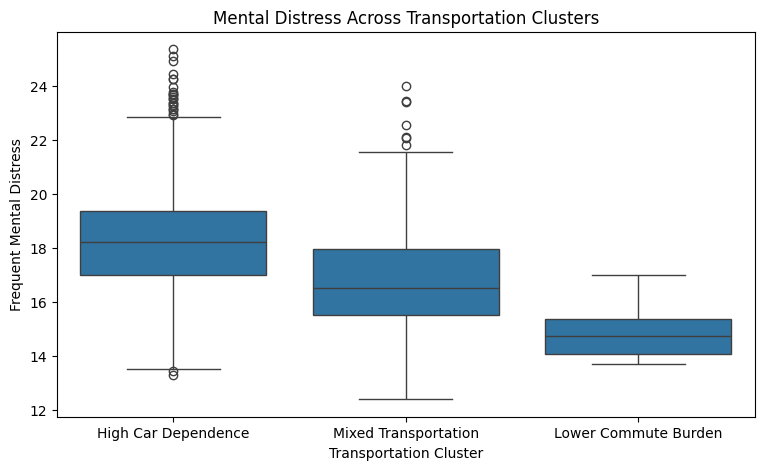

In [30]:
# Mental Distress Across Clusters

cluster_names = {
    0: "High Car Dependence",
    1: "Lower Commute Burden",
    2: "Mixed Transportation"
}

cluster_data["cluster_label"] = cluster_data["cluster"].map(cluster_names)

plt.figure(figsize=(9,5))

sns.boxplot(
    data=cluster_data,
    x="cluster_label",
    y="frequent_mental_distress"
)

plt.title("Mental Distress Across Transportation Clusters")
plt.xlabel("Transportation Cluster")
plt.ylabel("Frequent Mental Distress")

plt.show()

## Linear Regression Baseline Model

In [31]:
# Train model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
preds = lr.predict(X_test)

# Metrics
rmse = np.sqrt(mean_squared_error(y_test, preds))
mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)

print("LINEAR REGRESSION RESULTS")
print("-------------------------")
print("RMSE:", round(rmse, 3))
print("MAE:", round(mae, 3))
print("R²:", round(r2, 3))

LINEAR REGRESSION RESULTS
-------------------------
RMSE: 1.734
MAE: 1.338
R²: 0.12


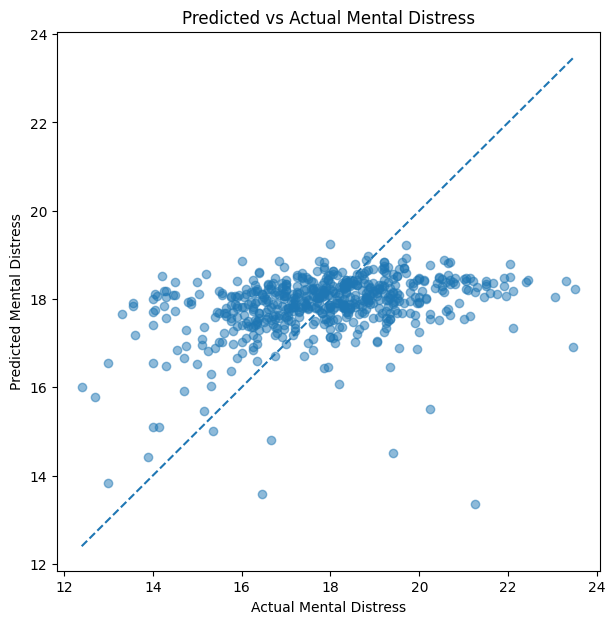

In [32]:
# Visualize Predicted vs Actual

plt.figure(figsize=(7,7))

plt.scatter(y_test, preds, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel("Actual Mental Distress")
plt.ylabel("Predicted Mental Distress")
plt.title("Predicted vs Actual Mental Distress")

plt.show()

## Random Forest

In [33]:
# Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize model
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

# Train
rf.fit(X_train, y_train)

# Predict
rf_preds = rf.predict(X_test)

# Metrics
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_r2 = r2_score(y_test, rf_preds)

print("RANDOM FOREST RESULTS")
print("---------------------")
print("RMSE:", round(rf_rmse, 3))
print("MAE:", round(rf_mae, 3))
print("R²:", round(rf_r2, 3))

RANDOM FOREST RESULTS
---------------------
RMSE: 1.712
MAE: 1.343
R²: 0.142


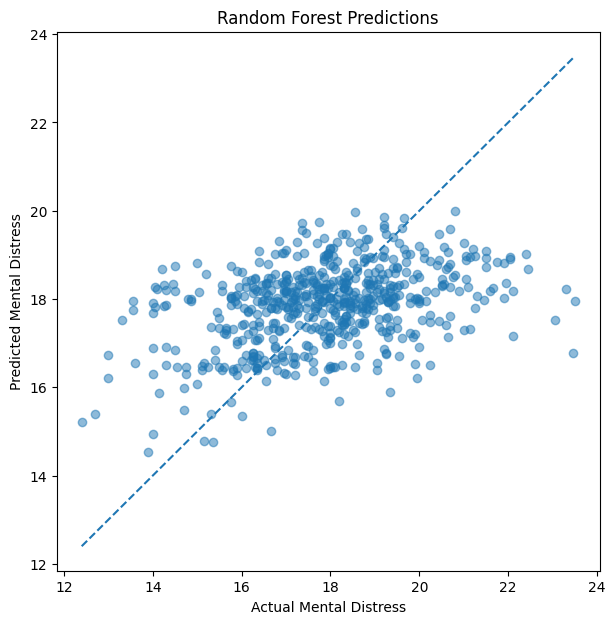

In [34]:
# Random Forest: Predicted vs Actual

import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.scatter(y_test, rf_preds, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel("Actual Mental Distress")
plt.ylabel("Predicted Mental Distress")
plt.title("Random Forest Predictions")

plt.show()

                Feature  Importance
0     drive_alone_share    0.719299
1  public_transit_share    0.211937
2    long_commute_share    0.068764


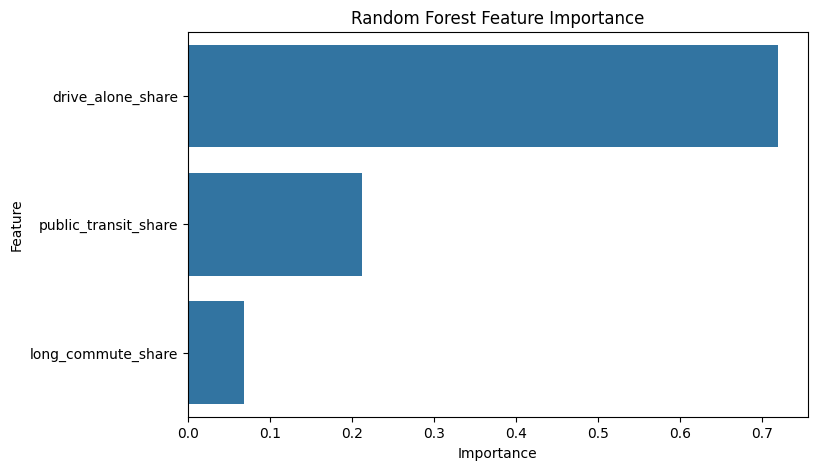

In [35]:
# Random Forest Feature Importance

rf_features = X_train.columns

importance_df = pd.DataFrame({
    "Feature": rf_features,
    "Importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df)

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")

plt.show()

## Gradient Boosting Regression

In [36]:
# Gradient Boosting Regressor

from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# Train
gbr.fit(X_train, y_train)

# Predict
gbr_preds = gbr.predict(X_test)

# Metrics
gbr_rmse = np.sqrt(mean_squared_error(y_test, gbr_preds))
gbr_mae = mean_absolute_error(y_test, gbr_preds)
gbr_r2 = r2_score(y_test, gbr_preds)

print("GRADIENT BOOSTING RESULTS")
print("-------------------------")
print("RMSE:", round(gbr_rmse, 3))
print("MAE:", round(gbr_mae, 3))
print("R²:", round(gbr_r2, 3))

GRADIENT BOOSTING RESULTS
-------------------------
RMSE: 1.7
MAE: 1.327
R²: 0.154


                Feature  Importance
0     drive_alone_share    0.749790
1  public_transit_share    0.163171
2    long_commute_share    0.087039


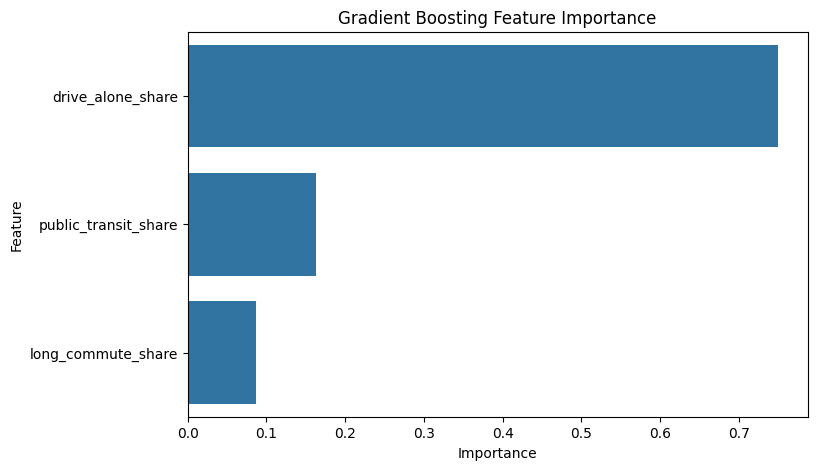

In [37]:
# Gradient Boosting Feature Importance

gbr_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": gbr.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(gbr_importance)

plt.figure(figsize=(8,5))

sns.barplot(
    data=gbr_importance,
    x="Importance",
    y="Feature"
)

plt.title("Gradient Boosting Feature Importance")
plt.show()

In [38]:
comparison_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "RMSE": [
        rmse,
        rf_rmse,
        gbr_rmse,
        xgb_rmse
    ],
    "MAE": [
        mae,
        rf_mae,
        gbr_mae,
        xgb_mae
    ],
    "R2": [
        r2,
        rf_r2,
        gbr_r2,
        xgb_r2
    ]
}).round(3)

comparison_df

NameError: name 'xgb_rmse' is not defined

## XGBoost

In [ ]:
# XGBoost Regressor

from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

# Train
xgb.fit(X_train, y_train)

# Predict
xgb_preds = xgb.predict(X_test)

# Metrics
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_mae = mean_absolute_error(y_test, xgb_preds)
xgb_r2 = r2_score(y_test, xgb_preds)

print("XGBOOST RESULTS")
print("----------------")
print("RMSE:", round(xgb_rmse, 3))
print("MAE:", round(xgb_mae, 3))
print("R²:", round(xgb_r2, 3))

In [ ]:
# XGBoost Feature Importance

xgb_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)

print(xgb_importance)

plt.figure(figsize=(8,5))

sns.barplot(
    data=xgb_importance,
    x="Importance",
    y="Feature"
)

plt.title("XGBoost Feature Importance")

plt.show()

## Model Comparison Table

In [ ]:
# Model Comparison Table

comparison_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],

    "RMSE": [
        rmse,
        rf_rmse,
        xgb_rmse
    ],

    "MAE": [
        mae,
        rf_mae,
        xgb_mae
    ],

    "R2": [
        r2,
        rf_r2,
        xgb_r2
    ]
})

comparison_df = comparison_df.round(3)

comparison_df

In [ ]:
# Model Performance Comparison

plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison_df,
    x="Model",
    y="R2"
)

plt.title("Model Comparison: R² Scores")

plt.ylabel("R²")

plt.show()

## Ridge and Lasso Regression

In [ ]:
# Ridge and Lasso Regression

from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# -------------------------------------
# Ridge Regression
# -------------------------------------

ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

ridge_preds = ridge_model.predict(X_test)

ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_preds))
ridge_mae = mean_absolute_error(y_test, ridge_preds)
ridge_r2 = r2_score(y_test, ridge_preds)

print("RIDGE REGRESSION RESULTS")
print("------------------------")
print("RMSE:", round(ridge_rmse, 3))
print("MAE:", round(ridge_mae, 3))
print("R²:", round(ridge_r2, 3))


# -------------------------------------
# Lasso Regression
# -------------------------------------

lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha=0.001))
])

lasso_model.fit(X_train, y_train)

lasso_preds = lasso_model.predict(X_test)

lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_preds))
lasso_mae = mean_absolute_error(y_test, lasso_preds)
lasso_r2 = r2_score(y_test, lasso_preds)

print("\nLASSO REGRESSION RESULTS")
print("------------------------")
print("RMSE:", round(lasso_rmse, 3))
print("MAE:", round(lasso_mae, 3))
print("R²:", round(lasso_r2, 3))

In [ ]:
# Expanded Model Comparison Table

comparison_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Random Forest",
        "XGBoost"
    ],

    "RMSE": [
        rmse,
        ridge_rmse,
        lasso_rmse,
        rf_rmse,
        xgb_rmse
    ],

    "MAE": [
        mae,
        ridge_mae,
        lasso_mae,
        rf_mae,
        xgb_mae
    ],

    "R2": [
        r2,
        ridge_r2,
        lasso_r2,
        rf_r2,
        xgb_r2
    ]
})

comparison_df = comparison_df.round(3)

comparison_df